In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Housing.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/housing-prices-dataset",
  file_path
)

# 1. Procesamiento del Dataset

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

columnas_binarias = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in columnas_binarias:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

X = df.drop('price', axis=1)
y = df['price']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = pd.DataFrame(scaler_X.fit_transform(X_train_raw), columns=X_train_raw.columns)
y_train = pd.Series(scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten())

X_test = pd.DataFrame(scaler_X.transform(X_test_raw), columns=X_test_raw.columns)
y_test = pd.Series(scaler_y.transform(y_test_raw.values.reshape(-1, 1)).flatten())

print(f"Datos listos. Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Datos listos. Train: 436 filas | Test: 109 filas


# 2. Grid Search de Modelos

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from sklearn.metrics import r2_score

# Espacio de búsqueda
optimizadores = ['sgd', 'adam']
learning_rates = [0.001, 0.0001]
batch_sizes = [16, 32, 64]
regularizaciones = ['ninguna', 'dropout', 'l2', 'ambas']
usar_early_stop = [True, False]
usar_reduce_lr = [True, False]

# Generamos todas las combinaciones posibles
combinaciones = list(itertools.product(
    optimizadores, learning_rates, batch_sizes, regularizaciones, usar_early_stop, usar_reduce_lr
))

print(f"Iniciando Grid Search Exhaustivo: {len(combinaciones)} modelos a entrenar. ¡Paciencia!\n")

# Construimos el modelo en funcion de los hiperparámetros actuales
def construir_modelo_grid(opt_name, lr, reg_type):
    modelo = Sequential()
    modelo.add(Input(shape=(X_train.shape[1],)))
    
    if reg_type in ['l2', 'ambas']:
        modelo.add(Dense(64, activation='relu', kernel_regularizer=l2(0.005)))
    else:
        modelo.add(Dense(64, activation='relu'))
        
    if reg_type in ['dropout', 'ambas']:
        modelo.add(Dropout(0.2))
        
    if reg_type in ['l2', 'ambas']:
        modelo.add(Dense(32, activation='relu', kernel_regularizer=l2(0.005)))
    else:
        modelo.add(Dense(32, activation='relu'))
        
    modelo.add(Dense(1, activation='linear'))

    if opt_name == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr, momentum=0.9)
        
    modelo.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return modelo

# Entrenamiento de todos los modelos
resultados_grid = []

for idx, (opt, lr, batch, reg, early_s, red_lr) in enumerate(combinaciones):
    K.clear_session()
    
    lista_callbacks = []
    if early_s:
        lista_callbacks.append(EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True))
    if red_lr:
        lista_callbacks.append(ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001))
    
    modelo = construir_modelo_grid(opt, lr, reg)
    
    historia = modelo.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=batch,
        callbacks=lista_callbacks if len(lista_callbacks) > 0 else None,
        verbose=0
    )
    
    predicciones = modelo.predict(X_test, verbose=0).flatten()
    r2 = r2_score(y_test, predicciones)
    epocas_usadas = len(historia.history['loss'])
    
    resultados_grid.append({
        'Optimizador': opt.upper(),
        'LR': lr,
        'Batch': batch,
        'Regularización': reg.upper(),
        'EarlyStop': 'Sí' if early_s else 'No',
        'ReduceLR': 'Sí' if red_lr else 'No',
        'Épocas': epocas_usadas,
        'R² Test': round(r2, 4)
    })
    
    if (idx + 1) % 10 == 0:
        print(f"Progreso: {idx + 1}/{len(combinaciones)} modelos entrenados...")

# Resultados
df_resultados = pd.DataFrame(resultados_grid)

# Ordenamos del mejor al peor R2
df_resultados = df_resultados.sort_values(by='R² Test', ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🏆 TOP 10 MEJORES MODELOS DE LA CUADRÍCULA 🏆")
print("="*50)
display(df_resultados.head(10))

print("\n" + "="*50)
print("💀 TOP 5 PEORES MODELOS (Para ver qué evitar) 💀")
print("="*50)
display(df_resultados.tail(5))

Iniciando Grid Search Exhaustivo: 192 modelos a entrenar. ¡Paciencia!


Progreso: 10/192 modelos entrenados...
Progreso: 20/192 modelos entrenados...
Progreso: 30/192 modelos entrenados...
Progreso: 40/192 modelos entrenados...
Progreso: 50/192 modelos entrenados...
Progreso: 60/192 modelos entrenados...
Progreso: 70/192 modelos entrenados...
Progreso: 80/192 modelos entrenados...
Progreso: 90/192 modelos entrenados...
Progreso: 100/192 modelos entrenados...
Progreso: 110/192 modelos entrenados...
Progreso: 120/192 modelos entrenados...
Progreso: 130/192 modelos entrenados...
Progreso: 140/192 modelos entrenados...
Progreso: 150/192 modelos entrenados...
Progreso: 160/192 modelos entrenados...
Progreso: 170/192 modelos entrenados...
Progreso: 180/192 modelos entrenados...
Progreso: 190/192 modelos entrenados...

🏆 TOP 10 MEJORES MODELOS DE LA CUADRÍCULA 🏆


,Optimizador,LR,Batch,Regularización,EarlyStop,ReduceLR,Épocas,R² Test
0,ADAM,0.0010,16,L2,Sí,No,100,0.6771
1,ADAM,0.0010,32,AMBAS,Sí,No,100,0.6736
2,ADAM,0.0010,16,AMBAS,Sí,No,74,0.6718
3,ADAM,0.0010,32,L2,Sí,No,100,0.6697
4,ADAM,0.0010,32,AMBAS,No,No,100,0.6696
5,ADAM,0.0010,16,L2,Sí,Sí,68,0.6692
6,SGD,0.0010,16,NINGUNA,No,No,100,0.6672
7,ADAM,0.0001,32,NINGUNA,No,Sí,100,0.6627
8,ADAM,0.0010,64,AMBAS,Sí,Sí,100,0.6618
9,ADAM,0.0010,16,AMBAS,Sí,Sí,94,0.6615



💀 TOP 5 PEORES MODELOS (Para ver qué evitar) 💀


,Optimizador,LR,Batch,Regularización,EarlyStop,ReduceLR,Épocas,R² Test
187,SGD,0.0001,64,DROPOUT,Sí,No,100,0.1013
188,SGD,0.0001,32,DROPOUT,Sí,No,100,0.0712
189,SGD,0.0001,64,DROPOUT,No,No,100,0.0663
190,SGD,0.0001,64,AMBAS,Sí,No,100,0.0497
191,SGD,0.0001,64,L2,No,No,100,0.0299


Podemos observar que tras esta búsqueda exhaustiva, los peores modelos tienen en común un **leraning_rate bajo** con **SDG** como optimizador. Esto se debe a que este optimzador **necesita más impulso** que Adams, por lo que con un learning_rate bajo no tiene potencial.

Como modelo ganador tenemos una combinación de **Adam** con un **Batch Size pequeño** (16) y regularización **L2**, que ha logrado encontrar un patrón mucho más sólido en los datos que en el anterior notebook, con un $R^2$ de 0.67 consiguiendo explicar aproximadamente un 67% del comportamiento del precio.

# 3. Construcción del modelo

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

K.clear_session()

# Hiperparámetros ganadores del Grid Search
LR = 0.001
BATCH_SIZE = 16
EPOCHS = 100

# Añadimos la Regularización L2 que demostró ser ganadora
modelo_final = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    Dense(1, activation='linear')
])

modelo_final.compile(optimizer=Adam(learning_rate=LR), loss='mse', metrics=['mae'])

# Early Stopping activado según los resultados del Grid Search
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print(f"Entrenando el modelo definitivo con ADAM, LR={LR}, Batch={BATCH_SIZE}, L2 Regularization...")
historia = modelo_final.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)

# Predicciones para comparar Train vs Test
pred_train = modelo_final.predict(X_train, verbose=0).flatten()
pred_test = modelo_final.predict(X_test, verbose=0).flatten()

mae_train = mean_absolute_error(y_train, pred_train)
mae_test = mean_absolute_error(y_test, pred_test)

print("\n--- 4.4 EVALUACIÓN DE SOBREAJUSTE ---")
print(f"MAE en Entrenamiento: {mae_train:.4f}")
print(f"MAE en Test (Validación): {mae_test:.4f}")
print(f"Diferencia (Test - Train): {mae_test - mae_train:.4f}")

Entrenando el modelo definitivo con ADAM, LR=0.001, Batch=16, L2 Regularization...

--- 4.4 EVALUACIÓN DE SOBREAJUSTE ---
MAE en Entrenamiento: 0.0710
MAE en Test (Validación): 0.0913
Diferencia (Test - Train): 0.0203


Como podemos observar, el modelo tiene poco error en ambos casos, tanto en train como en test. La diferencia entre los errores es baja por lo que el modelo **NO presenta principios de overfiting**.

# 4. Presentación de Resultados

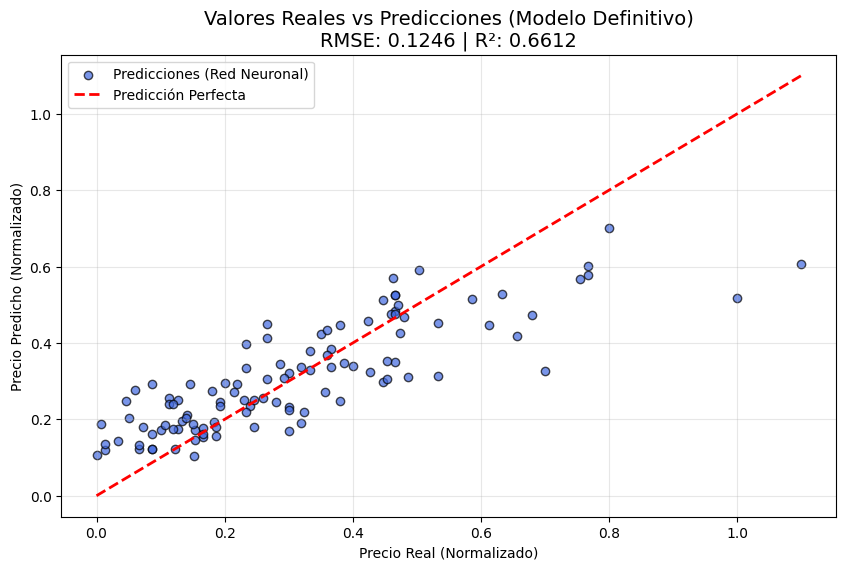


--- 5.2 ANÁLISIS DE ERRORES ---
Total de casas en test: 109
Casas con desviación > 10%: 83 (76.1%)

--- 5.3 COMPARATIVA: RED NEURONAL vs REGRESIÓN LINEAL ---
🎯 RED NEURONAL (Nuestro Modelo Optimizado):
   RMSE: 0.1246  |  R²: 0.6612

📉 REGRESIÓN LINEAL (Baseline Clásico):
   RMSE: 0.1261  |  R²: 0.6529

🏆 ¡VICTORIA! La Red Neuronal ha superado a la Regresión Lineal gracias al ajuste de hiperparámetros.


In [8]:
from sklearn.linear_model import LinearRegression

# Evaluación de Predicciones
rmse_nn = np.sqrt(mean_squared_error(y_test, pred_test))
r2_nn = r2_score(y_test, pred_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_test, alpha=0.7, color='royalblue', edgecolor='k', label='Predicciones (Red Neuronal)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.title(f'Valores Reales vs Predicciones (Modelo Definitivo)\nRMSE: {rmse_nn:.4f} | R²: {r2_nn:.4f}', fontsize=14)
plt.xlabel('Precio Real (Normalizado)')
plt.ylabel('Precio Predicho (Normalizado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Anáisis de Errores (> 10%)
# Añadimos 1e-8 para evitar división por cero
error_porcentual = (np.abs(pred_test - y_test) / (y_test + 1e-8)) * 100

df_errores = pd.DataFrame({
    'Real': y_test,
    'Predicho': pred_test,
    'Error_%': error_porcentual
})

errores_graves = df_errores[df_errores['Error_%'] > 10.0]

print("\n--- 5.2 ANÁLISIS DE ERRORES ---")
print(f"Total de casas en test: {len(y_test)}")
print(f"Casas con desviación > 10%: {len(errores_graves)} ({(len(errores_graves)/len(y_test)*100):.1f}%)")

# Comparación con Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("\n--- 5.3 COMPARATIVA: RED NEURONAL vs REGRESIÓN LINEAL ---")
print("🎯 RED NEURONAL (Nuestro Modelo Optimizado):")
print(f"   RMSE: {rmse_nn:.4f}  |  R²: {r2_nn:.4f}")
print("\n📉 REGRESIÓN LINEAL (Baseline Clásico):")
print(f"   RMSE: {rmse_lr:.4f}  |  R²: {r2_lr:.4f}")

if r2_nn > r2_lr:
    print("\n🏆 ¡VICTORIA! La Red Neuronal ha superado a la Regresión Lineal gracias al ajuste de hiperparámetros.")
else:
    print("\n🤝 EMPATE/DERROTA TÉCNICA: Pese a la optimización exhaustiva, la Regresión Lineal clásica sigue siendo un modelo formidable para este pequeño dataset.")

En cuanto a la **Evaluación de Predicciones**, la gráfica es bastante parecida a la del notebook anterior. Sigue fallando con los outliers porque los datos de esos casos siguen siendo escasos para su aprendizaje.

En cuanto al **Análisis de Errores**, como ya comentamos en el notebook anterior, al estar normalizados los precios la división por numeros cercanos a cero que son la mayoría (casas de bajo/medio valor) el porcentaje se dispara matemáticamente aunque la diferencia respecto del valor real de la casa sea baja. Pese a seguir "disparado" el porcentaje de error ha bajado entorno a un 5% respecto del anterior notebook.

En cuanto a la **Comparación con la Regresión Lineal**, la RNA ha sido superior a la Regresión Lineal por muy poco (< 1%) a diferencia del anterior notebook en el que el $R^2$ de la RNA se desplomó.

# 5. Deployment

## 5.1 Serialización del Modelo

In [10]:
import joblib

# 1. Guardar el modelo ganador en formato Keras
modelo_final.save('modelo_viviendas.keras')

# 2. Guardar AMBOS escaladores
joblib.dump(scaler_X, 'scaler_X_housing.joblib')
joblib.dump(scaler_y, 'scaler_y_housing.joblib')

print("✅ Serialización completada con éxito.")
print("Archivos generados:")
print("- modelo_viviendas.keras")
print("- scaler_X_housing.joblib")
print("- scaler_y_housing.joblib")

✅ Serialización completada con éxito.
Archivos generados:
- modelo_viviendas.keras
- scaler_X_housing.joblib
- scaler_y_housing.joblib


## 5.2 Creación de API de Predicción

In [11]:
from flask import Flask, request, jsonify
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd
import threading
import time

app = Flask(__name__)

# Cargamos el modelo y los dos escaladores
modelo_api = tf.keras.models.load_model('modelo_viviendas.keras')
escalador_X = joblib.load('scaler_X_housing.joblib')
escalador_y = joblib.load('scaler_y_housing.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        datos = request.get_json()
        df_input = pd.DataFrame([datos])
        
        df_input = df_input[escalador_X.feature_names_in_]
        
        X_escalado = escalador_X.transform(df_input)
        
        pred_norm = modelo_api.predict(X_escalado, verbose=0)
        
        precio_real = escalador_y.inverse_transform(pred_norm)[0][0]
        
        return jsonify({
            'status': 'success',
            'precio_estimado': float(precio_real)
        })
        
    except Exception as e:
        return jsonify({'error': str(e)}), 400

def run_api():    
    app.run(port=5000, use_reloader=False, debug=False)

# Lanzar en segundo plano
thread = threading.Thread(target=run_api)
thread.daemon = True
thread.start()

time.sleep(2)
print("✅ API de Flask (Versión Dual-Scaler) corriendo en http://127.0.0.1:5000")

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


✅ API de Flask (Versión Dual-Scaler) corriendo en http://127.0.0.1:5000


In [13]:
import requests
import json

# Cogemos una casa de los datos CRUDOS (sin normalizar)
# Así simulamos a un usuario metiendo datos reales en un formulario web
casa_de_prueba = X_test_raw.iloc[0].to_dict()

print("Enviando estos datos REALES a la API:")
print(json.dumps(casa_de_prueba, indent=2))

# Hacemos la petición POST a nuestra API
url = 'http://127.0.0.1:5000/predict'
respuesta = requests.post(url, json=casa_de_prueba)

if respuesta.status_code == 200:
    datos_respuesta = respuesta.json()
    precio = datos_respuesta['precio_estimado']
    
    print("\n" + "="*45)
    print("🏠 RESPUESTA DE LA API EN PRODUCCIÓN 🏠")
    print("="*45)
    print(f"La red neuronal estima que la casa vale:")
    print(f"{precio:,.2f}")
    print("="*45)
else:
    print(f"Error en la API. Código: {respuesta.status_code}")
    print(respuesta.text)

Enviando estos datos REALES a la API:
{
  "area": 5900,
  "bedrooms": 4,
  "bathrooms": 2,
  "stories": 2,
  "mainroad": 0,
  "guestroom": 0,
  "basement": 1,
  "hotwaterheating": 0,
  "airconditioning": 0,
  "parking": 1,
  "prefarea": 0,
  "furnishingstatus_semi-furnished": 0,
  "furnishingstatus_unfurnished": 1
}


127.0.0.1 - - [08/May/2026 11:29:39] "POST /predict HTTP/1.1" 200 -



🏠 RESPUESTA DE LA API EN PRODUCCIÓN 🏠
La red neuronal estima que la casa vale:
4,827,842.00


# CONCLUSIONES